# Probability Made Simple
## PMF • PDF • CDF • Common Distributions
**Beginner-friendly study notes with explanations, Python examples, graphs, and practice.**

Based on your three-page PDF, **`2-finalpdf,pmf,cdf(1).pdf`**. The notebook expands every topic in the notes. All datasets below are small teaching examples or simulated data, not real research data.

> **Our main question:** What can happen, and how likely is each thing?

## Goal
By the end, you will be able to explain PMF, PDF, and CDF in plain English, calculate probabilities, read their graphs, choose a distribution, and explore a small house dataset.

**How to study:** Read one explanation, run the next cell, look at the result, then change one number. You do not need to know calculus before starting.

## Contents
1. Setup and tiny Python guide
2. Probability, random variables, and distributions
3. PMF: probability for countable values
4. CDF: probability collected up to a value
5. PDF: probability from area
6. How PDF and CDF connect
7. Comparing PMF, PDF, and CDF
8. Bernoulli distribution
9. Binomial distribution
10. Normal distribution
11. Poisson distribution
12. Lognormal distribution
13. Uniform distributions
14. House-data mini project: EDA and feature engineering
15. Common mistakes and revision sheet
16. Practice with worked answers
17. Checks and next steps

## 1. Setup
Open this file in **Jupyter Notebook**, **JupyterLab**, **VS Code**, or **Google Colab**. Choose a Python 3 kernel. Use **Run All** to run the whole notebook, or **Shift + Enter** to run one cell.

Outputs and graphs are included, so you can also read without running anything. The notebook does not need the original PDF, downloads, passwords, or any external dataset.

If imports fail, uncomment and run the installation line below once. Restart the kernel afterward if needed.

In [1]:
# Remove the # on the next line only if a package is missing.
# %pip install numpy pandas matplotlib scipy

import numpy as np                  # Helps us work with lists of numbers.
import pandas as pd                 # Helps us make and explore tables.
import matplotlib.pyplot as plt     # Draws graphs.
from scipy import stats             # Gives us ready-made probability functions.
from IPython.display import display # Displays a table neatly.

rng = np.random.default_rng(42)      # Makes our simulated examples repeatable.
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("Ready! Let's learn probability.")

Ready! Let's learn probability.


### A tiny Python guide
| Code | Super simple meaning |
|---|---|
| `x = 5` | Give the name `x` to the number 5. |
| `[1, 2, 3]` | A list of three values. |
| `np.array([1, 2, 3])` | A number list that NumPy can calculate with easily. |
| `values.sum()` | Add all the values. |
| `values <= 3` | Check which values are 3 or smaller. |
| `values[condition]` | Keep only values that pass the condition. |
| `np.cumsum(values)` | Keep a running total. |
| `np.linspace(0, 10, 100)` | Make 100 evenly spaced points from 0 to 10. |
| `f"{number:.2f}"` | Print a number with two digits after the decimal. |
| `plt.show()` | Display the graph. |

You will see comments beginning with `#`. Python ignores them; they explain the code to you.

## 2. Probability, random variables, and distributions
### 2.1 Probability means chance
Imagine a bag containing 3 red balls and 2 blue balls. Mix them well and pick one without looking. Assume each ball has the same chance of being selected.

$$P(\text{red})=\frac{\text{number of red balls}}{\text{total balls}}=\frac35=0.6=60\%.$$

- **0** means impossible.
- **1** means certain.
- **0.5** means a 50% chance.

The “favourable outcomes / total outcomes” shortcut requires equally likely outcomes. It is not a general rule for an unfair die.

In [2]:
red_balls = 3
total_balls = 5
probability_red = red_balls / total_balls  # / means divide.
print("Probability:", probability_red)
print(f"Percentage: {probability_red:.0%}")

Probability: 0.6
Percentage: 60%


### 2.2 A random variable is a number attached to an uncertain result
Roll a die. Before it lands, you do not know its result. Let **X** mean the number on top.

- Capital **X** is the random variable: “the die result.”
- Small **x** is a particular value, such as 4.
- $P(X=4)$ means “the chance that the result is 4.”

### 2.3 Discrete versus continuous
| Type | Easy meaning | Examples | Usual function |
|---|---|---|---|
| Discrete | Separate, countable possible values | Die result, number of rooms, calls received | PMF |
| Continuous | Values measured along a range | Height, time, exact age | PDF for the continuous models in this notebook |

**Count vs measure:** You count 3 rooms. You might measure 3.27 metres.

A stored decimal is not automatically continuous, and a stored integer is not automatically discrete in the underlying model. Age measured exactly is often modeled as continuous; age recorded in completed years is discrete. Prices recorded to the nearest paise are technically discrete, but a continuous model is often useful.

### 2.4 A distribution is a map of chances
A distribution tells us how chance is spread across possible values. Some values can be common and others rare.

A distribution does **not** have to be bell-shaped. It can be flat, right-skewed, left-skewed, or have several peaks. The mathematical function changes when the distribution changes.

**Three tools:** PMF describes chance at discrete values; PDF describes density for continuous values; CDF describes accumulated probability for either type.

## 3. PMF: Probability Mass Function
> **Think of a PMF as a shelf of separate boxes. Each box holds the chance of one value.**

For a fair six-sided die:
$$p(x)=P(X=x)=\frac16,\qquad x\in\{1,2,3,4,5,6\}.$$
Outside these values, the PMF is zero.

Two rules make a valid PMF:
1. Every probability is non-negative.
2. All probabilities add to 1: $\sum_x p(x)=1$.

Each probability is also at most 1. The symbol $\sum$ just means “add them.”

Total probability: 0.9999999999999999


,Die result,Probability
0,1,0.166667
1,2,0.166667
2,3,0.166667
3,4,0.166667
4,5,0.166667
5,6,0.166667


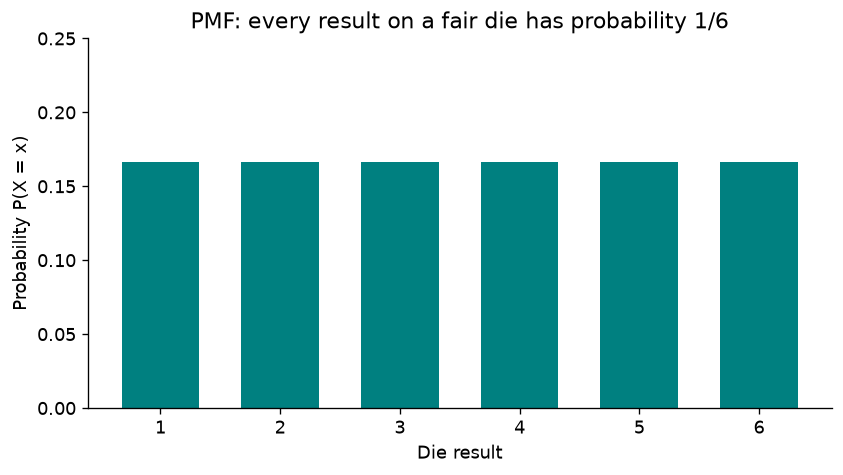

In [3]:
die_values = np.arange(1, 7)        # 1, 2, 3, 4, 5, 6; the stop value 7 is excluded.
die_pmf = np.full(6, 1 / 6)        # Make six equal probabilities.
display(pd.DataFrame({"Die result": die_values, "Probability": die_pmf}))
print("Total probability:", die_pmf.sum())

plt.bar(die_values, die_pmf, color="teal", width=0.65)
plt.xticks(die_values)
plt.ylim(0, 0.25)
plt.xlabel("Die result")
plt.ylabel("Probability P(X = x)")
plt.title("PMF: every result on a fair die has probability 1/6")
plt.show()

**Read the graph:** The bar at 4 has height 1/6, so the chance of rolling exactly 4 is 1/6. There is no possible die result of 2.5. We use separated bars to show separate outcomes.

### Add probabilities for a group of outcomes
To find the chance of 2 or less, add the chances of 1 and 2. To find an even result, add the chances of 2, 4, and 6.

In [4]:
probability_at_most_2 = die_pmf[die_values <= 2].sum()
probability_even = die_pmf[die_values % 2 == 0].sum()  # % gives the remainder.
print(f"P(X <= 2) = {probability_at_most_2:.4f} = 1/3")
print(f"P(even) = {probability_even:.2f} = 1/2")

P(X <= 2) = 0.3333 = 1/3
P(even) = 0.50 = 1/2


### A PMF does not need equal probabilities
Suppose a spinner has results 0, 1, and 2 with chances 0.2, 0.5, and 0.3. These are valid because they are non-negative and add to 1. Result 1 is the most likely.

In [5]:
spinner_values = np.array([0, 1, 2])
spinner_pmf = np.array([0.2, 0.5, 0.3])
display(pd.DataFrame({"Result": spinner_values, "PMF": spinner_pmf}))
print("P(result is 1 or 2):", spinner_pmf[spinner_values >= 1].sum())

P(result is 1 or 2): 0.8


,Result,PMF
0,0,0.2
1,1,0.5
2,2,0.3


## 4. CDF: Cumulative Distribution Function
> **Think of a CDF as a running total of chance, moving from left to right.**

**Cumulative** means “added up so far.” The correct full name is **Cumulative Distribution Function**, not “cumulative density function.”

$$F(x)=P(X\leq x).$$
Read this as: “F of x is the chance that X is x or smaller.”

For a fair die:
- $F(1)=1/6$.
- $F(2)=2/6=1/3$.
- $F(6)=6/6=1$.
- $F(2.5)=2/6$ because only 1 and 2 fit.

For a discrete variable, add the PMF values up to the cutoff.

,Result,PMF,CDF
0,1,0.166667,0.166667
1,2,0.166667,0.333333
2,3,0.166667,0.500000
3,4,0.166667,0.666667
4,5,0.166667,0.833333
5,6,0.166667,1.000000


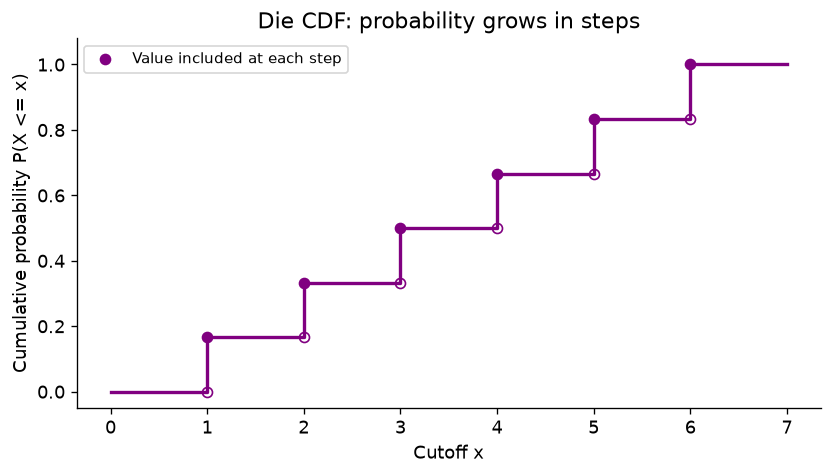

In [6]:
die_cdf = np.cumsum(die_pmf)  # Running total: 1/6, 2/6, ..., 6/6.
display(pd.DataFrame({"Result": die_values, "PMF": die_pmf, "CDF": die_cdf}))

# Extend the graph to show zero before 1 and one from 6 onward.
step_x = np.arange(0, 8)
step_y = np.r_[0, die_cdf, 1]
plt.step(step_x, step_y, where="post", color="purple", linewidth=2)
plt.scatter(die_values, die_cdf, color="purple", label="Value included at each step")
plt.scatter(die_values, np.r_[0, die_cdf[:-1]], facecolors="white", edgecolors="purple")
plt.xticks(step_x)
plt.xlabel("Cutoff x")
plt.ylabel("Cumulative probability P(X <= x)")
plt.title("Die CDF: probability grows in steps")
plt.ylim(-0.05, 1.08)
plt.legend(fontsize=9)
plt.show()

**Read the graph:** The CDF is flat between 2 and 3 because no new die result occurs there. At 3, it jumps by 1/6. The filled dot gives the value at the jump.

### Rules for every CDF
- It stays between 0 and 1.
- It never decreases: adding more possible outcomes cannot remove probability.
- Far enough to the left it approaches 0; far enough to the right it approaches 1.
- It is right-continuous: the value at a jump includes that jump.

### Use the CDF for intervals
$$P(a<X\leq b)=F(b)-F(a).$$
For a die, $P(2<X\leq4)=F(4)-F(2)=2/6$.

**Careful with discrete endpoints:** $P(2\leq X\leq4)=F(4)-F(1)=3/6$. The second question includes result 2.

In [7]:
def fair_die_cdf(cutoff):
    # Keep outcomes no larger than the cutoff, then add their probabilities.
    return die_pmf[die_values <= cutoff].sum()

print("F(2.5):", fair_die_cdf(2.5))
print("P(2 < X <= 4):", fair_die_cdf(4) - fair_die_cdf(2))
print("P(2 <= X <= 4):", fair_die_cdf(4) - fair_die_cdf(1))
print("P(X > 4):", 1 - fair_die_cdf(4))

F(2.5): 0.3333333333333333
P(2 < X <= 4): 0.3333333333333333
P(2 <= X <= 4): 0.5
P(X > 4): 0.33333333333333337


## 5. PDF: Probability Density Function
> **Think of a PDF as a curve above a number line. Probability is the area under a piece of the curve.**

A continuous value could be 35, 35.1, 35.12, and so on. We find the probability of a **range**, such as ages 35 to 45, using area.

$$P(a\leq X\leq b)=\int_a^b f(x)\,dx.$$

The long symbol $\int$ means “add up lots of tiny pieces of area.” You do not have to calculate it by hand here.

### Height is density; area is probability
- $f(40)$ is the **density** at 40.
- $P(35\leq X\leq45)$ is the **area** from 35 to 45.
- For these continuous models, $P(X=40)=0$: a single point has zero width and therefore zero area.

Probability zero at one exact point does not mean a continuous variable cannot take a value. Any measured value is also rounded to some precision.

### PDF rules
1. $f(x)\geq0$ everywhere.
2. The total area is 1: $\int_{-\infty}^{\infty}f(x)\,dx=1$.

**A PDF height can be greater than 1.** Probability is still never greater than 1. We will demonstrate this with a narrow uniform distribution.

### Worked model: ages around 40
For teaching only, assume ages follow a normal curve with mean 40 and standard deviation 5. This is a simplified model, not a claim that all real ages are normally distributed. These parameters are introduced here; the sketches in your PDF do not specify an exact fitted distribution.

Density at 40: 0.0798 per year
Probability from 35 to 45: 68.27%
Probability at or below 45: 84.13%


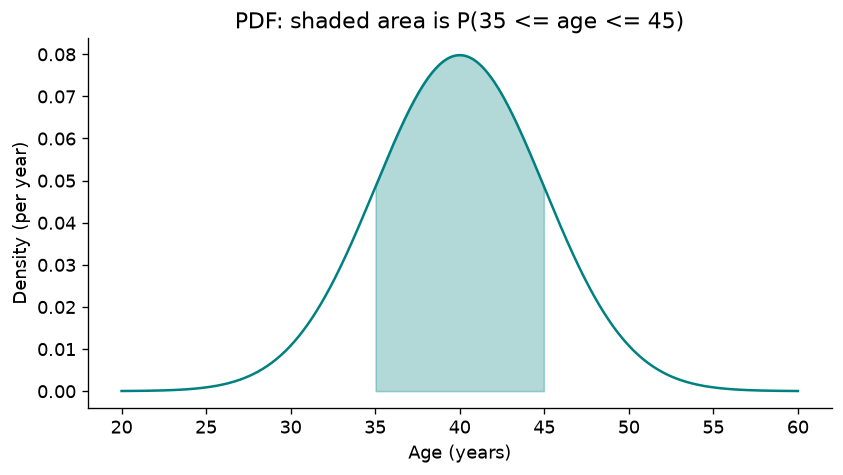

In [8]:
age_model = stats.norm(loc=40, scale=5)  # Centre at 40; spread controlled by 5.
age_grid = np.linspace(20, 60, 600)
age_density = age_model.pdf(age_grid)   # Height of the PDF at each point.
selected = (age_grid >= 35) & (age_grid <= 45)

plt.plot(age_grid, age_density, color="teal")
plt.fill_between(age_grid, age_density, where=selected, color="teal", alpha=0.3)
plt.xlabel("Age (years)")
plt.ylabel("Density (per year)")
plt.title("PDF: shaded area is P(35 <= age <= 45)")
plt.show()

print(f"Density at 40: {age_model.pdf(40):.4f} per year")
print(f"Probability from 35 to 45: {age_model.cdf(45) - age_model.cdf(35):.2%}")
print(f"Probability at or below 45: {age_model.cdf(45):.2%}")

**What this tells us:** The shaded middle area is about 68.27%. The chance of an age at or below 45 is about 84.13% in this example. A density height such as 0.0798 per year is not a 7.98% probability of being exactly 40.

For a continuous model, including or excluding a single endpoint does not change the probability. So `P(35 < X < 45)` equals `P(35 <= X <= 45)` here.

## 6. How PDF and CDF connect
### 6.1 Area builds the CDF
$$F(x)=\int_{-\infty}^{x} f(t)\,dt.$$
In simple words: **the CDF at x collects all PDF area to the left of x.** The letter $t$ is just a temporary name for positions as we add up area.

### 6.2 The CDF slope gives the PDF
Where the CDF is differentiable for these smooth models:
$$f(x)=F'(x)=\frac{dF(x)}{dx}.$$

A steep CDF means probability is being added quickly, so density is high. A flat CDF means very little probability is being added.

A slope between two points is:
$$\frac{F(x_2)-F(x_1)}{x_2-x_1}.$$

This is **average density over the interval**, not necessarily the exact density at one point. Using a very small interval gives a local approximation.

For a discrete die CDF, the PMF is found from **jump sizes**, not from an ordinary smooth slope.

Average density from 38 to 44: 0.073928
CDF slope near 40: 0.079788
PDF at 40:        0.079788


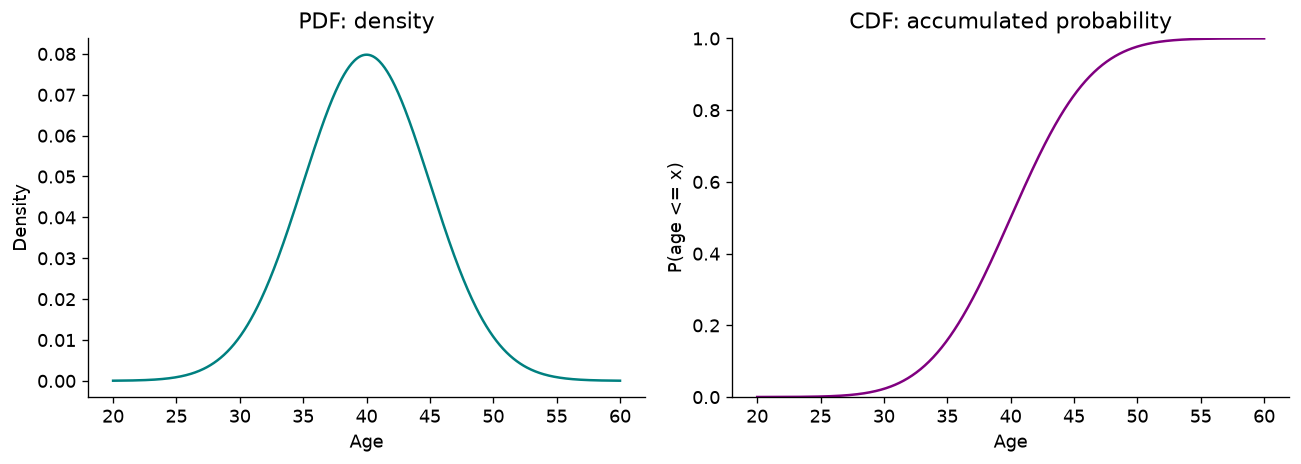

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(age_grid, age_model.pdf(age_grid), color="teal")
axes[0].set(title="PDF: density", xlabel="Age", ylabel="Density")
axes[1].plot(age_grid, age_model.cdf(age_grid), color="purple")
axes[1].set(title="CDF: accumulated probability", xlabel="Age", ylabel="P(age <= x)")
axes[1].set_ylim(0, 1)
fig.tight_layout()
plt.show()

left_age, right_age = 38, 44
average_density = (age_model.cdf(right_age) - age_model.cdf(left_age)) / (right_age - left_age)
small_step = 0.001
slope_near_40 = (age_model.cdf(40 + small_step) - age_model.cdf(40 - small_step)) / (2 * small_step)
print(f"Average density from 38 to 44: {average_density:.6f}")
print(f"CDF slope near 40: {slope_near_40:.6f}")
print(f"PDF at 40:        {age_model.pdf(40):.6f}")

### A histogram is a data summary, not automatically the true PDF
A histogram puts observed values into bins. A density histogram uses heights so that **bar height × bin width** gives the fraction of observations in that bin. Its total area is 1.

A smooth PDF is a mathematical model. A histogram may resemble that model, but it will change with the sample and bin choices.

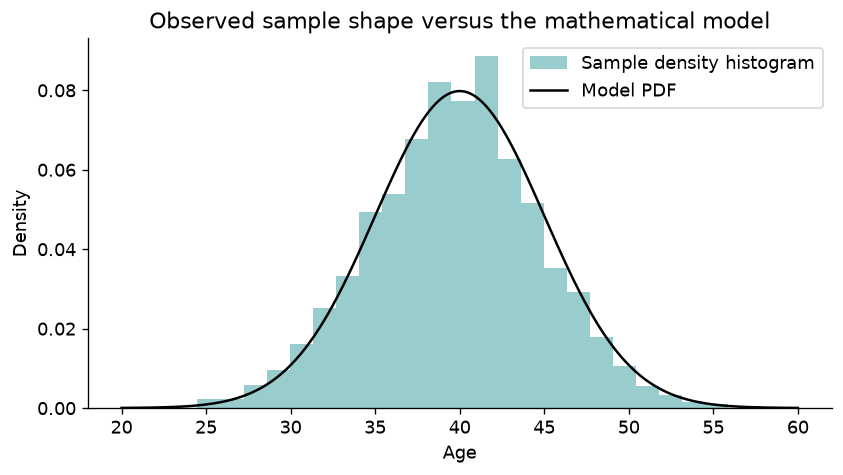

In [10]:
sample_ages = rng.normal(40, 5, size=2000)  # Simulated ages for a teaching example.
plt.hist(sample_ages, bins=25, density=True, alpha=0.4, color="teal", label="Sample density histogram")
plt.plot(age_grid, age_model.pdf(age_grid), color="black", label="Model PDF")
plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Observed sample shape versus the mathematical model")
plt.legend()
plt.show()

## 7. PMF, PDF, and CDF side by side
| Question | PMF | PDF | CDF |
|---|---|---|---|
| Full name | Probability Mass Function | Probability Density Function | Cumulative Distribution Function |
| Used for | Discrete values | Continuous models with a density | Both |
| Meaning | $P(X=x)$ | Density $f(x)$ | $P(X\leq x)$ |
| Typical picture | Separate bars or dots | Curve or flat density | Steps or continuous rising curve |
| Range probability | Add relevant probabilities | Find area over the range | Subtract CDF values with correct endpoints |
| Must stay between 0 and 1? | Yes | No; density can exceed 1 | Yes |
| Total rule | Probabilities sum to 1 | Area equals 1 | Rises from 0 toward 1 |

**Memory aid:** **Mass = exact value. Density = area. Cumulative = collected chance.**

The distribution names below describe different models. PMF/PDF/CDF are ways to describe a model, not competing model names.

### A quick SciPy guide
| Method | What it does |
|---|---|
| `.pmf(k)` | Probability of exactly k for a discrete model |
| `.pdf(x)` | Density at x for a continuous model |
| `.cdf(x)` | Probability at or below x |
| `.sf(x)` | Probability above x, the survival function |
| `.ppf(q)` | Cutoff whose cumulative probability reaches q, a quantile |
| `.rvs(size=..., random_state=...)` | Simulates observations |

## 8. Bernoulli distribution: one yes/no trial
> **One coin toss. One delivery that succeeds or fails. One house that is seaside or not.**

Use 1 for “success” and 0 for “failure.” Success is just the event we are counting; it does not have to mean something good.

If success has chance $p$:
$$P(X=1)=p,\qquad P(X=0)=1-p.$$

The compact formula is $P(X=x)=p^x(1-p)^{1-x}$ for $x\in\{0,1\}$. The two separate probabilities above are easier to remember.

**Assumption:** One binary outcome with a specified chance of success. Example: a teaching model gives a delivery an 80% chance of being on time. Then $p=0.8$.

**Mean:** $p$. **Variance:** $p(1-p)$. The mean is a long-run average; variance describes spread. A single Bernoulli result is still only 0 or 1.

,Outcome,Probability
0,Late (0),0.2
1,On time (1),0.8


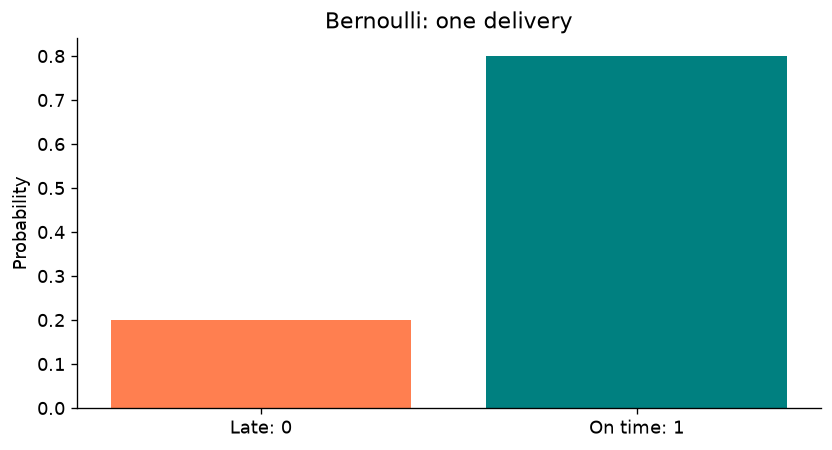

In [11]:
success_probability = 0.8
bernoulli_model = stats.bernoulli(p=success_probability)
binary_values = np.array([0, 1])
display(pd.DataFrame({"Outcome": ["Late (0)", "On time (1)"],
                      "Probability": bernoulli_model.pmf(binary_values)}))
plt.bar(binary_values, bernoulli_model.pmf(binary_values), color=["coral", "teal"])
plt.xticks(binary_values, ["Late: 0", "On time: 1"])
plt.ylabel("Probability")
plt.title("Bernoulli: one delivery")
plt.show()

## 9. Binomial distribution: successes in a fixed number of trials
> **Bernoulli counts success in one trial. Binomial counts successes across n trials.**

Example: Toss a fair coin 5 times. Let X count the number of heads.

Required assumptions:
1. The number of trials $n$ is fixed.
2. Each trial has two outcomes.
3. Each trial has the same success probability $p$.
4. Trials are independent: one result does not change another's chance.

$$P(X=k)=\binom nk p^k(1-p)^{n-k},\qquad k=0,1,\ldots,n.$$

- $\binom nk$ counts the ways to place k successes among n trials.
- $p^k$ gives the success part for one arrangement.
- $(1-p)^{n-k}$ gives the failure part.

For exactly 3 heads in 5 fair tosses: $10\times(0.5)^3\times(0.5)^2=0.3125$.

**Mean:** $np$. **Variance:** $np(1-p)$. Dependence or changing success chances can make this model unsuitable.

P(exactly 3 heads): 31.25%
P(at most 2 heads): 50.00%
P(at least 3 heads): 50.00%


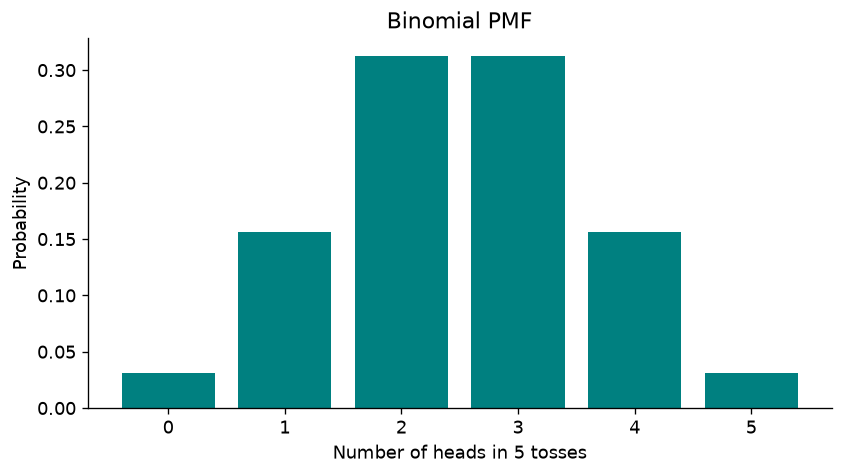

In [12]:
number_of_trials = 5
binomial_model = stats.binom(n=number_of_trials, p=0.5)
head_counts = np.arange(0, number_of_trials + 1)
print(f"P(exactly 3 heads): {binomial_model.pmf(3):.2%}")
print(f"P(at most 2 heads): {binomial_model.cdf(2):.2%}")
print(f"P(at least 3 heads): {binomial_model.sf(2):.2%}")  # >2 means >=3 for integer counts.
plt.bar(head_counts, binomial_model.pmf(head_counts), color="teal")
plt.xticks(head_counts)
plt.xlabel("Number of heads in 5 tosses")
plt.ylabel("Probability")
plt.title("Binomial PMF")
plt.show()

## 10. Normal / Gaussian distribution: a symmetric bell
> **Most values are near the centre. Values far from the centre are less common.**

Two parameters control this model:
- $\mu$ (mu): mean, the centre.
- $\sigma$ (sigma): standard deviation, the spread. It must be positive.

$$f(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).$$

You do not need to memorise this to use the example. `exp` is the exponential function. The formula makes a symmetric bell with total area 1.

**Mean:** $\mu$. **Variance:** $\sigma^2$.

For a normal model, approximately 68.27%, 95.45%, and 99.73% lie within 1, 2, and 3 standard deviations of the mean.

**When it is reasonable:** Continuous measurements that are roughly symmetric and bell-shaped. A normal model allows every real number, including negatives. Check whether this makes sense for your variable. Salaries and house prices are not automatically normal.

### Standardisation: how far from the centre?
$$z=\frac{x-\mu}{\sigma}.$$
A z-score of 2 means two standard deviations above the mean.

Within 1 standard deviation(s): 68.27%
Within 2 standard deviation(s): 95.45%
Within 3 standard deviation(s): 99.73%
z-score of 130: 2.0
90th percentile: 119.22


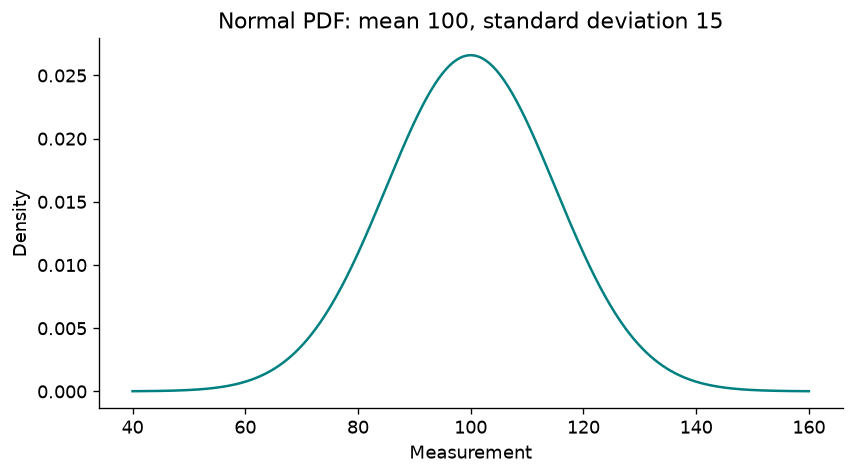

In [13]:
normal_model = stats.norm(loc=100, scale=15)
measurement_grid = np.linspace(40, 160, 500)
plt.plot(measurement_grid, normal_model.pdf(measurement_grid), color="teal")
plt.xlabel("Measurement")
plt.ylabel("Density")
plt.title("Normal PDF: mean 100, standard deviation 15")
plt.show()
for multiplier in [1, 2, 3]:
    lower = 100 - multiplier * 15
    upper = 100 + multiplier * 15
    chance = normal_model.cdf(upper) - normal_model.cdf(lower)
    print(f"Within {multiplier} standard deviation(s): {chance:.2%}")
print("z-score of 130:", (130 - 100) / 15)
print(f"90th percentile: {normal_model.ppf(0.90):.2f}")

## 11. Poisson distribution: events in a fixed interval
> **How many calls arrive in one hour? How many errors occur per page?**

Let $\lambda$ (lambda) mean the expected number of events in the interval. Suppose the average is 3 calls per hour.

$$P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!},\qquad k=0,1,2,\ldots$$

$k!$ means factorial: $3!=3\times2\times1=6$, and $0!=1$. The constant $e$ is about 2.718.

**Usual process assumptions:** Events occur independently, at a constant average rate, and events do not arrive in clusters at exactly the same instant. Real traffic can violate these assumptions.

**Mean and variance:** both $\lambda$. For two hours at the same rate, use $\lambda=6$.

**Binomial vs Poisson:** Binomial counts successes out of a fixed number of trials; Poisson counts events within an interval with no fixed maximum count.

P(exactly 2 calls): 22.40%
P(no calls): 4.98%
P(more than 5 calls): 8.39%
Probability beyond the displayed counts: 0.000016


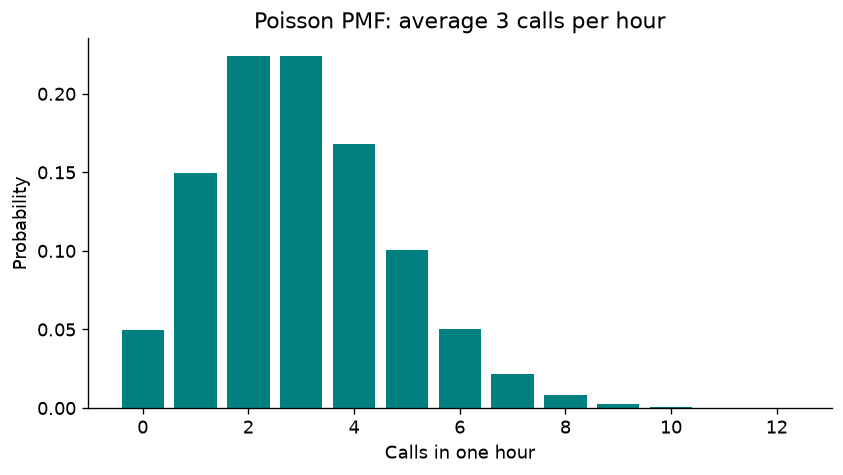

In [14]:
poisson_model = stats.poisson(mu=3)  # SciPy calls the Poisson mean 'mu'.
call_counts = np.arange(0, 13)
print(f"P(exactly 2 calls): {poisson_model.pmf(2):.2%}")
print(f"P(no calls): {poisson_model.pmf(0):.2%}")
print(f"P(more than 5 calls): {poisson_model.sf(5):.2%}")
plt.bar(call_counts, poisson_model.pmf(call_counts), color="teal")
plt.xlabel("Calls in one hour")
plt.ylabel("Probability")
plt.title("Poisson PMF: average 3 calls per hour")
plt.show()
print(f"Probability beyond the displayed counts: {poisson_model.sf(12):.6f}")

## 12. Lognormal distribution: positive values with a long right tail
> **Many moderate values, with a few much larger ones.**

A variable X is lognormal when its natural logarithm is normal:
$$\ln(X)\sim N(\mu,\sigma^2),\qquad X>0.$$

The natural log shrinks large positive numbers more strongly than small ones. If Y is normal, then $X=e^Y$ is lognormal.

Its PDF is:
$$f(x)=\frac{1}{x\sigma\sqrt{2\pi}}\exp\left(-\frac{(\ln x-\mu)^2}{2\sigma^2}\right),\quad x>0.$$

Here $\mu$ and $\sigma$ describe **log(X)**, not the original X.

- Median: $e^\mu$.
- Mean: $e^{\mu+\sigma^2/2}$, larger than the median when $\sigma>0$.

Possible applications include positive quantities produced by multiplying growth factors. Income and prices can be right-skewed, but a right-skewed histogram alone does not prove a lognormal model.

**SciPy mapping:** `stats.lognorm(s=sigma, scale=np.exp(mu), loc=0)` uses the standard unshifted lognormal model.

Model median: 20.09
Model mean: 24.05


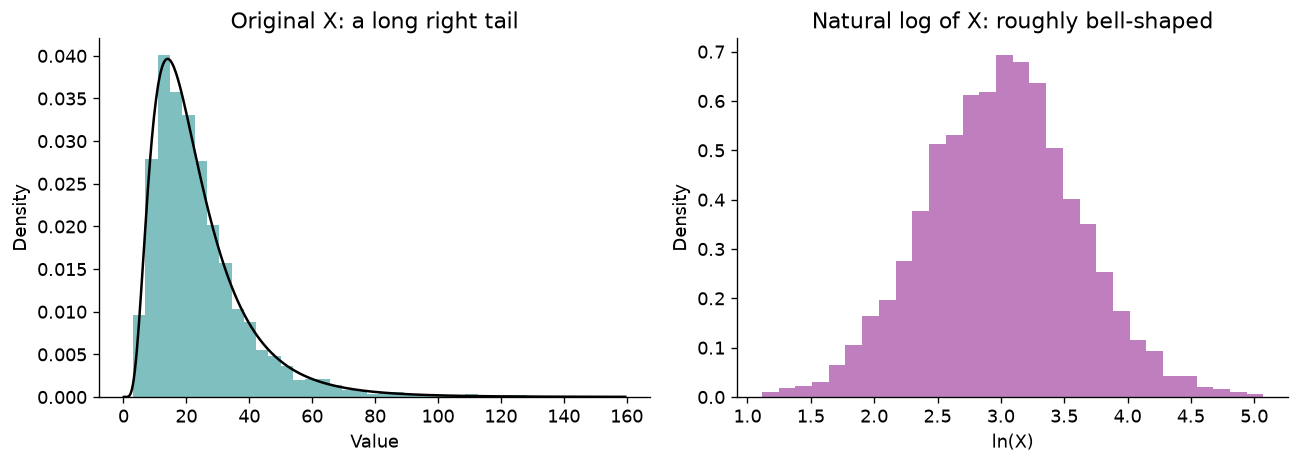

In [15]:
log_mean = 3.0
log_std = 0.6
lognormal_model = stats.lognorm(s=log_std, scale=np.exp(log_mean), loc=0)
positive_values = lognormal_model.rvs(size=3000, random_state=rng)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(positive_values, bins=40, density=True, color="teal", alpha=0.5)
positive_grid = np.linspace(0.1, positive_values.max(), 500)
axes[0].plot(positive_grid, lognormal_model.pdf(positive_grid), color="black")
axes[0].set(title="Original X: a long right tail", xlabel="Value", ylabel="Density")
axes[1].hist(np.log(positive_values), bins=30, density=True, color="purple", alpha=0.5)
axes[1].set(title="Natural log of X: roughly bell-shaped", xlabel="ln(X)", ylabel="Density")
fig.tight_layout()
plt.show()
print(f"Model median: {lognormal_model.median():.2f}")
print(f"Model mean: {lognormal_model.mean():.2f}")

## 13. Uniform distributions: equal chances or equal density
### 13.1 Discrete uniform
A fair die is discrete uniform: a finite set of values has equal probabilities. For m equally likely values, each probability is $1/m$.

### 13.2 Continuous uniform
Imagine a waiting time equally spread over 0 to 10 minutes. Equal-length intervals inside this range have equal probabilities.

For $X\sim U(a,b)$ with $a<b$:
$$f(x)=\frac{1}{b-a}\quad\text{for }a\leq x\leq b,$$
with zero density outside. Its CDF is 0 below a, $(x-a)/(b-a)$ within the range, and 1 above b.

$$P(c\leq X\leq d)=\frac{d-c}{b-a}\quad\text{when }a\leq c\leq d\leq b.$$

For 0 to 10 minutes, the chance of 2 to 5 minutes is $3/10=30\%$.

**Mean:** $(a+b)/2$. **Variance:** $(b-a)^2/12$.

**Correction to the handwritten list:** Uniform can have a **PMF** (discrete) or a **PDF** (continuous).

P(2 <= wait <= 5): 30%
Density at 0.1: 5.0
Total rectangle area = height * width: 1.0


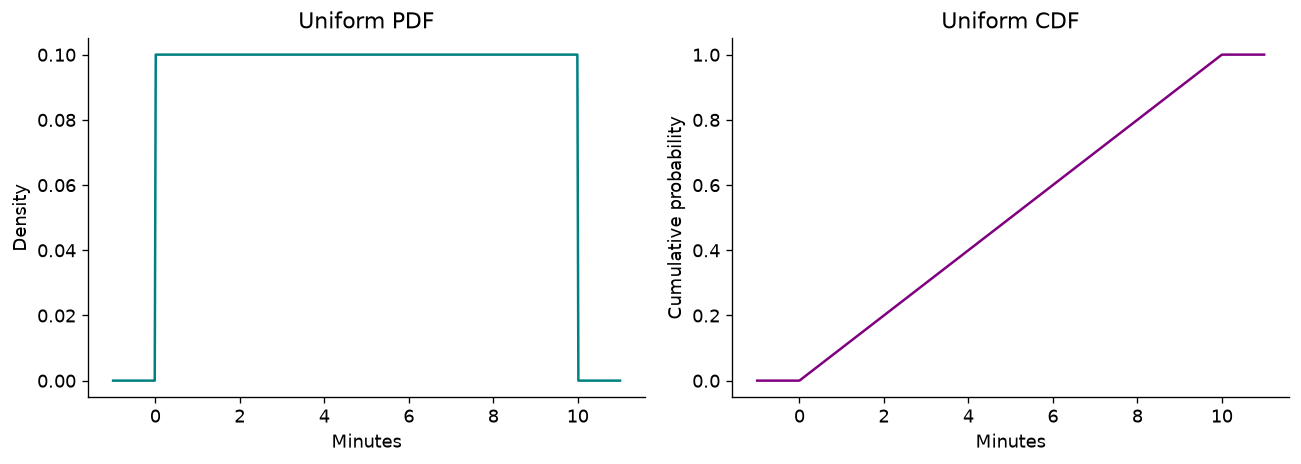

In [16]:
waiting_model = stats.uniform(loc=0, scale=10)  # scale is width, not the upper endpoint.
wait_grid = np.linspace(-1, 11, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(wait_grid, waiting_model.pdf(wait_grid), color="teal")
axes[0].set(title="Uniform PDF", xlabel="Minutes", ylabel="Density")
axes[1].plot(wait_grid, waiting_model.cdf(wait_grid), color="purple")
axes[1].set(title="Uniform CDF", xlabel="Minutes", ylabel="Cumulative probability")
fig.tight_layout()
plt.show()
print(f"P(2 <= wait <= 5): {waiting_model.cdf(5) - waiting_model.cdf(2):.0%}")

# A narrow interval demonstrates why density may exceed 1.
narrow_model = stats.uniform(loc=0, scale=0.2)
print("Density at 0.1:", narrow_model.pdf(0.1))
print("Total rectangle area = height * width:", narrow_model.pdf(0.1) * 0.2)

**Read that carefully:** For the narrow model the height is 5, but the width is 0.2. The area is `5 × 0.2 = 1`. This is a valid PDF.

### Choosing a model: quick guide
| Situation | Candidate model | Main condition to check |
|---|---|---|
| One yes/no outcome | Bernoulli | Binary outcome |
| Success count in n trials | Binomial | Fixed n, independent trials, constant p |
| Event count in an interval | Poisson | Independent events, stable rate |
| Roughly symmetric continuous values | Normal | Bell shape and plausible support |
| Positive values whose logs are normal | Lognormal | Positive values and log-scale fit |
| Equally likely separate outcomes | Discrete uniform | Equal probabilities |
| Equal density over a bounded range | Continuous uniform | Equal chance for equal-length intervals |

These are candidates, not automatic choices. Domain knowledge and observed data both matter.

## 14. Mini project: understand a house dataset
Your PDF lists house size, number of rooms, location, floor, seaside status, and price. Let us connect each one to probability.

### 14.1 Decide what each column means
| Column | Meaning | Type / handling |
|---|---|---|
| Size | Area in square feet | Usually modeled as continuous; a histogram can show its shape |
| Rooms | Number of rooms | Discrete count; empirical PMF |
| Location | Area name | Categorical label; category proportions, not a numeric density |
| Floor | Floor number | Discrete ordered value; empirical PMF |
| Seaside | 1 = yes, 0 = no | Binary; Bernoulli is a possible marginal model |
| Price | Amount in lakh rupees | Often modeled as continuous; examine its shape first |

**EDA** means exploratory data analysis: look at the data, find patterns, and check problems before modeling.

**Feature engineering** means creating useful inputs from existing columns. Example: divide house size by rooms to get area per room.

The following table is invented for learning. It is too small to justify fitting a reliable price model or making market claims.

In [17]:
houses = pd.DataFrame({
    "size_sqft": [600, 750, 820, 900, 1050, 1200, 1350, 1500, 1800, 2100, 2500, 3200],
    "rooms": [1, 2, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    "location": ["North", "South", "North", "East", "South", "East", "North", "South", "East", "North", "South", "East"],
    "floor": [0, 1, 2, 0, 3, 1, 4, 2, 5, 3, 1, 6],
    "seaside": [0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1],
    "price_lakh": [25, 31, 35, 48, 46, 55, 72, 69, 105, 110, 165, 240]
})
display(houses)
print("Missing values:")
print(houses.isna().sum())
print("Duplicate rows:", houses.duplicated().sum())

Missing values:
size_sqft     0
rooms         0
location      0
floor         0
seaside       0
price_lakh    0
dtype: int64
Duplicate rows: 0


,size_sqft,rooms,location,floor,seaside,price_lakh
0,600,1,North,0,0,25
1,750,2,South,1,0,31
2,820,2,North,2,0,35
3,900,2,East,0,1,48
4,1050,3,South,3,0,46
5,1200,3,East,1,0,55
6,1350,3,North,4,1,72
7,1500,3,South,2,0,69
8,1800,4,East,5,1,105
9,2100,4,North,3,0,110


### 14.2 Build an empirical PMF
**Empirical** means “from observed data.” Count each room value, then divide by the number of houses.

If 4 of 12 houses have 3 rooms, the observed proportion is 4/12. It is the exact probability when selecting uniformly from these 12 rows; it is only an estimate of a wider market probability.

Fraction with at most 3 rooms: 66.67%


,Count,Empirical PMF,Empirical CDF
rooms,,,
1,1,0.083333,0.083333
2,3,0.250000,0.333333
3,4,0.333333,0.666667
4,2,0.166667,0.833333
5,2,0.166667,1.000000


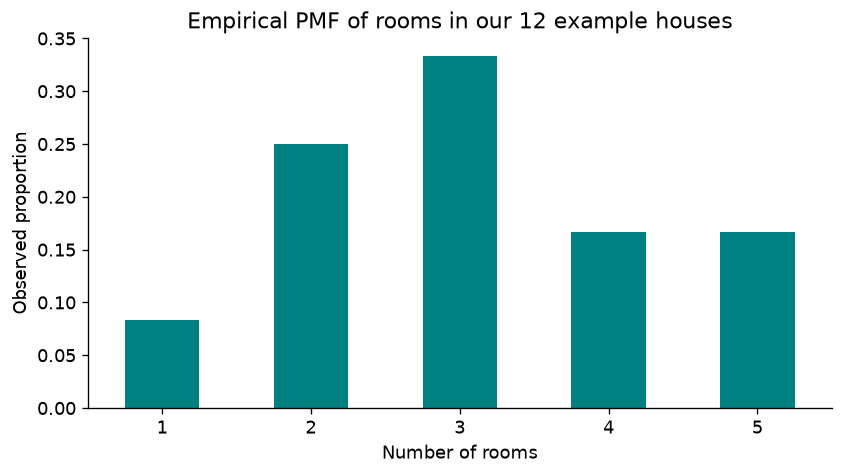

In [18]:
room_counts = houses["rooms"].value_counts().sort_index()
room_pmf = room_counts / len(houses)
room_cdf = room_pmf.cumsum()
display(pd.DataFrame({"Count": room_counts, "Empirical PMF": room_pmf, "Empirical CDF": room_cdf}))
room_pmf.plot(kind="bar", color="teal", rot=0)
plt.xlabel("Number of rooms")
plt.ylabel("Observed proportion")
plt.title("Empirical PMF of rooms in our 12 example houses")
plt.show()
print(f"Fraction with at most 3 rooms: {(houses['rooms'] <= 3).mean():.2%}")

### 14.3 Histograms and an empirical CDF for prices
A histogram groups prices into ranges. An **empirical CDF (ECDF)** tells us the fraction of observed prices at or below each cutoff. It is a step function even when the underlying variable is treated as continuous, because the dataset has only finitely many observations.

A few expensive houses can create a long right tail. That observation alone does not establish a particular distribution.

Fraction priced at or below 100 lakh: 66.67%


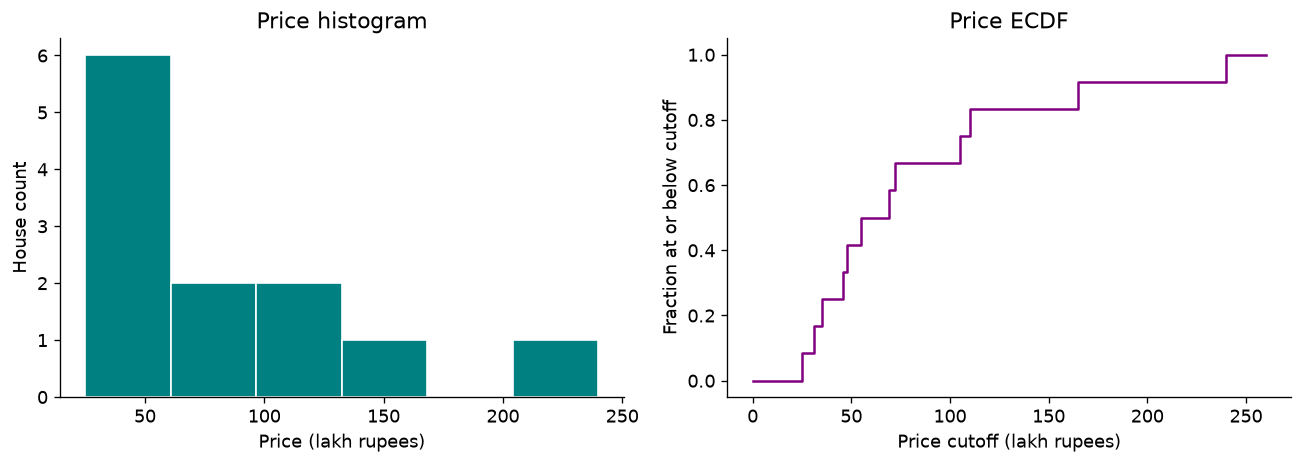

In [19]:
sorted_prices = np.sort(houses["price_lakh"].to_numpy())
price_ecdf = np.arange(1, len(sorted_prices) + 1) / len(sorted_prices)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sorted_prices, bins=6, color="teal", edgecolor="white")
axes[0].set(title="Price histogram", xlabel="Price (lakh rupees)", ylabel="House count")
axes[1].step(np.r_[0, sorted_prices, 260], np.r_[0, price_ecdf, 1], where="post", color="purple")
axes[1].set(title="Price ECDF", xlabel="Price cutoff (lakh rupees)", ylabel="Fraction at or below cutoff")
fig.tight_layout()
plt.show()
print(f"Fraction priced at or below 100 lakh: {(houses['price_lakh'] <= 100).mean():.2%}")

### 14.4 Categories and binary data
For location, count each category. There is no meaningful mathematical distance between “North” and “East” just because we assign them numbers. For seaside status, the fraction of 1s is the observed success proportion.

In [20]:
display(houses["location"].value_counts(normalize=True).rename("Observed proportion").to_frame())
print(f"Observed seaside proportion: {houses['seaside'].mean():.2%}")

# Make a useful size feature. Our example has no zero-room homes.
houses["area_per_room"] = houses["size_sqft"] / houses["rooms"]

# Natural log helps us inspect positive prices on a compressed scale.
houses["log_price"] = np.log(houses["price_lakh"])
display(houses[["size_sqft", "rooms", "area_per_room", "price_lakh", "log_price"]].head())

# Give each location a separate yes/no column; no fake ranking is introduced.
location_features = pd.get_dummies(houses["location"], prefix="location", dtype=int)
display(location_features.head())

Observed seaside proportion: 41.67%


,Observed proportion
location,
North,0.333333
South,0.333333
East,0.333333


,size_sqft,rooms,area_per_room,price_lakh,log_price
0,600,1,600.0,25,3.218876
1,750,2,375.0,31,3.433987
2,820,2,410.0,35,3.555348
3,900,2,450.0,48,3.871201
4,1050,3,350.0,46,3.828641


,location_East,location_North,location_South
0,0,1,0
1,0,0,1
2,0,1,0
3,1,0,0
4,0,0,1


**Practical lessons:**
- Validate room counts before division: dividing by zero would be a problem.
- Ordinary `np.log` requires positive values. It cannot directly handle a zero or negative price.
- If predicting price, `log_price` can be a transformed **target**. Do not use a feature calculated from the unknown price to predict that same price; that leaks the answer.
- Not every continuous column needs to be normal for machine learning.
- For real prediction work, split training and test data before learning preprocessing settings from the data.

This mini project is about understanding distributions, not training a prediction model.

## 15. Common mistakes and revision sheet
| Mistake | Correct idea |
|---|---|
| “CDF means cumulative density function.” | It means cumulative **distribution** function. |
| “A PDF height is probability.” | Probability is area under the PDF. |
| “PDF values must be at most 1.” | Density can exceed 1; total area must be 1. |
| “A CDF gives probability of exactly x.” | It gives probability at or below x. |
| “A discrete CDF is a smooth line.” | It jumps at outcomes with positive probability. |
| “Every distribution is normal.” | Distribution shapes differ. |
| “Uniform is always discrete.” | Uniform can be discrete or continuous. |
| “Any right-skewed data are lognormal.” | Check the model; shape alone is insufficient. |
| “A slope over a wide interval is the PDF at a point.” | It is average density; a local derivative gives point density where it exists. |
| “Histogram bin counts are PDF heights.” | Counts and density use different scales. |
| “F(b) - F(a) includes a for a discrete variable.” | It gives $P(a<X\leq b)$. |
| “Location codes 1, 2, 3 are continuous measurements.” | Numeric labels do not create meaningful distances. |

### Useful notation
| Symbol | Meaning |
|---|---|
| $P$ | Probability |
| $X$ | Random variable |
| $x$ | A particular value or cutoff |
| $p(x)$ | PMF |
| $f(x)$ | PDF |
| $F(x)$ | CDF |
| $\leq$ | Less than or equal to |
| $\sum$ | Add separate terms |
| $\int$ | Add tiny areas |
| $\mu$ | Mean, or log-scale mean for the lognormal parameterisation |
| $\sigma$ | Standard deviation, or log-scale standard deviation |
| $\lambda$ | Expected Poisson count in the interval |

### Three questions to ask yourself
1. **What is X?** Define the thing you count or measure.
2. **What event do I want?** Exactly, at most, above, or between?
3. **What model is reasonable?** Check type and assumptions before calculating.

## 16. Practice: try before reading the answers
Use a fresh cell to solve each exercise. All necessary imports are already available.

1. Fair die: What is the probability of exactly 5? Of a result at most 3?
2. Fair die: Find `P(2 <= X <= 5)`. Which endpoints must be included?
3. Is `[0.2, 0.3, 0.6]` a valid PMF? Why?
4. Bernoulli with `p=0.7`: What is the failure probability?
5. Ten independent trials with `p=0.2`: Find the chance of exactly 2 successes.
6. Normal with mean 50 and standard deviation 10: Find `P(40 <= X <= 60)`.
7. Poisson with mean 4 per hour: Find the chance of zero arrivals in an hour.
8. Uniform from 2 to 6: Find the PDF height and `P(3 <= X <= 5)`.
9. Why can a continuous PDF have height 5 without breaking probability rules?
10. From the house table, find the fraction of houses with at least 4 rooms.
11. Which model is a candidate for one yes/no outcome? For a count of events per hour?
12. If you take the natural log of a lognormal variable, what distribution results?

**Experiment:** Change binomial `p` from 0.5 to 0.8 and redraw its PMF. Predict which way the bars will move first. Then increase a normal model's standard deviation and see how its curve becomes wider and lower.

### Worked answers: 1 to 5
1. Exactly 5 uses the PMF: 1/6. At most 3 adds three outcomes: 3/6.
2. Include 2, 3, 4, and 5: 4/6. Use `F(5) - F(1)`.
3. No: the probabilities add to 1.1, not 1.
4. Failure probability is `1 - 0.7 = 0.3`.
5. Use a binomial model because n is fixed and the independent trials have the same p.

In [21]:
print("1. Exactly 5:", 1 / 6, "| At most 3:", fair_die_cdf(3))
print("2. Between 2 and 5 inclusive:", fair_die_cdf(5) - fair_die_cdf(1))
print("3. Candidate PMF sum:", np.array([0.2, 0.3, 0.6]).sum())
print(f"4. Failure probability: {1 - 0.7:.1f}")
print(f"5. Exactly 2 successes: {stats.binom(n=10, p=0.2).pmf(2):.4f}")

1. Exactly 5: 0.16666666666666666 | At most 3: 0.5
2. Between 2 and 5 inclusive: 0.6666666666666666
3. Candidate PMF sum: 1.1
4. Failure probability: 0.3
5. Exactly 2 successes: 0.3020


### Worked answers: 6 to 12
6. Use the difference between CDF values. This is one standard deviation either side of the mean: about 68.27%.
7. A count of zero uses the Poisson PMF: about 1.83%.
8. Width is 4, so density is 1/4. The requested interval has width 2, so its probability is 2/4.
9. Height is density, and probability is area. A height of 5 over width 0.2 gives total area 1.
10. Four of the twelve houses have at least four rooms: 1/3.
11. Bernoulli for one yes/no outcome; Poisson is a candidate for event counts if its rate and independence assumptions are reasonable.
12. Normal, by the definition of a lognormal variable.

In [22]:
practice_normal = stats.norm(loc=50, scale=10)
print(f"6. Between 40 and 60: {practice_normal.cdf(60) - practice_normal.cdf(40):.2%}")
print(f"7. Zero arrivals: {stats.poisson(mu=4).pmf(0):.2%}")
practice_uniform = stats.uniform(loc=2, scale=4)
print("8. Density:", practice_uniform.pdf(4))
print("8. Interval probability:", practice_uniform.cdf(5) - practice_uniform.cdf(3))
print(f"10. At least 4 rooms: {(houses['rooms'] >= 4).mean():.2%}")

6. Between 40 and 60: 68.27%
7. Zero arrivals: 1.83%
8. Density: 0.25
8. Interval probability: 0.5
10. At least 4 rooms: 33.33%


## 17. Checks
The checks below verify the main worked calculations and probability rules. `assert` means “check that this is true.” `np.isclose` allows tiny rounding differences in computer calculations.

These checks confirm our examples; they do not establish that a model fits a real-world population.

In [23]:
assert np.all(die_pmf >= 0)
assert np.isclose(die_pmf.sum(), 1)
assert np.all(np.diff(die_cdf) >= 0)        # Running probability must never decrease.
assert np.isclose(die_cdf[-1], 1)
assert np.isclose(fair_die_cdf(2), 1 / 3)
assert np.isclose(fair_die_cdf(4) - fair_die_cdf(1), 1 / 2)
assert np.isclose(binomial_model.pmf(3), 0.3125)
assert np.isclose(age_model.cdf(45) - age_model.cdf(35), 0.682689492, atol=1e-8)
assert np.isclose(narrow_model.pdf(0.1) * 0.2, 1)
assert np.isclose(room_pmf.sum(), 1)
assert np.isclose((houses["rooms"] >= 4).mean(), 1 / 3)
print("All checks passed.")

All checks passed.


## Next steps
1. Explain PMF, PDF, and CDF out loud using the die and waiting-time examples.
2. Change one parameter in each distribution and predict the graph before running it.
3. Create your own small dataset and calculate an empirical PMF or ECDF.
4. Next, study expected value, variance, sampling, and confidence intervals.

### Coverage of your PDF
| Source page | Topics explained here |
|---|---|
| 1 | Distribution meaning, discrete/continuous variables, PMF, fair die, cumulative probability, CDF |
| 2 | PDF, area, density, continuous CDF, slope/gradient, non-negativity, total area, changing distribution shapes |
| 3 | Bernoulli, binomial, normal, Poisson, lognormal, uniform, house columns, EDA and feature engineering |

### Notes about the source
The PDF is a set of handwritten teaching notes, with illustrative curves rather than a supplied numerical dataset. All numerical models and datasets introduced here are explicitly worked teaching examples. The terminology and endpoint clarifications in this notebook help make the source ideas mathematically precise.

**You now have the core idea:** PMF gives chance at separate values, PDF gives density whose area is chance, and CDF gives chance collected up to a cutoff.